In [85]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [86]:
df = pd.read_csv("../data/train_clear.csv")

In [87]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [88]:
X_encoded = pd.get_dummies(X, drop_first=True).astype(int)

In [89]:
X_scaled = StandardScaler().fit_transform(X_encoded)

In [90]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [91]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
feature_importance = []

In [92]:
all_y_true = []
all_y_pred = []

In [93]:
for fold, (train_index, val_index) in enumerate(skf.split(X_scaled, y_encoded)):
    X_train, X_val = X_scaled[train_index], X_scaled[val_index]
    y_train, y_val = y_encoded[train_index], y_encoded[val_index]
    
    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    
    score = model.score(X_val, y_val)
    cv_scores.append(score)

    all_y_true.extend(y_val)
    all_y_pred.extend(y_pred)
    
    fold_imp = np.abs(model.coef_).mean(axis=0)
    feature_importance.append(fold_imp)

In [94]:
scores = np.array(cv_scores)

In [95]:
f"Точность логистической регрессии: {scores.mean():0.3f} ± {scores.std():0.3f}"

'Точность логистической регрессии: 0.807 ± 0.005'

In [96]:
mean_importance = np.mean(feature_importance, axis=0)

importance_df = pd.DataFrame(
    {"feature": X_encoded.columns, "importance": mean_importance}
).sort_values("importance", ascending=False)

print(importance_df.head(10))

            feature  importance
13              ALT    1.789369
14              AST    1.736051
15        Bilirubin    0.990483
4      Sym_Jaundice    0.781323
17        Platelets    0.506852
10  Comorb_Diabetes    0.406099
8    Sym_Dark_Urine    0.396851
3       Sym_Fatigue    0.362660
16          Albumin    0.358959
6       Sym_Itching    0.291209


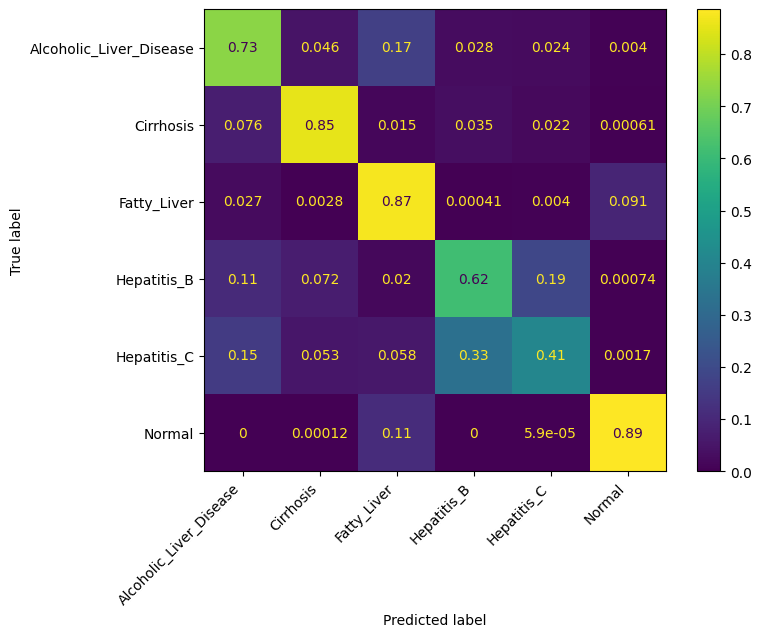

In [97]:
fig, ax = plt.subplots(figsize=(8, 6))
disp_raw = ConfusionMatrixDisplay.from_predictions(
    all_y_true, 
    all_y_pred, 
    display_labels=le.classes_,
    ax=ax,
    normalize="true"
)
plt.xticks(rotation=45, ha='right')
plt.show()